# Bai tap
Hãy thay đổi cấu trúc mô hình MLP hiện tại bằng cách sử dụng 2 lớp Dense (Fully Connected) với số lượng nút ẩn lần lượt là 32 và 16. Giữ nguyên lớp đầu ra và các hàm kích hoạt ReLU cho các lớp ẩn. Sau đó huấn luyện lại mô hình và so sánh các chỉ số đánh giá (Accuracy, Precision, Recall, F1-score) với mô hình ban đầu.

Train với batch size 16, epoch 50, in kết quả các metrics Precsion, Recall, F1 Score và nhận xét


1. Analyze
2. Preprocess data
3. Feature Engineering
4. Build Model Pipeline
5. Measure performance of the model.
6. Which metric is your main metric for this problem and why? What is your main model as well as their params and why? Your comment


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable.
3. Data Analysis is correct or make sense
4. The data preprocessing is correct or make sense
5. The Feature engineering is correct or make sense
6. Model pipeline
7. Any other additional process will be considered a small plus point.

This dataset contains information about credit applicants, including demographic, financial, and contact-related data. It is designed for use in building predictive models to detect credit fraud or assess credit risk.

Each row represents a unique applicant, and the target variable indicates whether the applicant is likely to default or be involved in fraudulent activity.

| Column Name         | Description                                                                                                      |
| ------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **ID**              | Unique identifier for each applicant.                                                                           |
| **GENDER**          | Gender of the applicant (e.g., Male, Female).                                                                   |
| **CAR**             | Indicates whether the applicant owns a car (Yes/No).                                                            |
| **REALITY**         | Indicates whether the applicant owns real estate property (Yes/No).                                             |
| **NO_OF_CHILD**     | Number of children the applicant has.                                                                           |
| **INCOME**          | Applicant’s monthly income (in local currency).                                                                 |
| **INCOME_TYPE**     | Type of income source (e.g., Working, Pensioner, Student).                                                      |
| **EDUCATION_TYPE**  | Level of education (e.g., Secondary, Higher Education, Incomplete Higher).                                     |
| **FAMILY_TYPE**     | Type of family structure (e.g., Married, Single, Civil Marriage).                                               |
| **HOUSE_TYPE**      | Type of housing the applicant lives in (e.g., House, Apartment, Municipal).                                     |
| **FLAG_MOBIL**      | Indicator if the applicant has a mobile phone (1 = Yes, 0 = No).                                                |
| **WORK_PHONE**      | Indicator if the applicant has a work phone (1 = Yes, 0 = No).                                                  |
| **PHONE**           | Indicator if the applicant has a home phone (1 = Yes, 0 = No).                                                  |
| **E_MAIL**          | Indicator if the applicant has an email address (1 = Yes, 0 = No).                                              |
| **FAMILY SIZE**     | Total number of family members.                                                                                 |
| **BEGIN_MONTH**     | Number of months since the applicant first applied for credit (usually negative indicating months in the past). |
| **AGE**             | Applicant's age (in years).                                                                                     |
| **YEARS_EMPLOYED**  | Number of years the applicant has been employed.                                                                |
| **TARGET**          | Target label: 1 if fraudulent or default case, 0 if not. See [CSDN Blog][1] for reference.                      |


## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
# from google.colab import drive

# drive.mount("/content/drive")

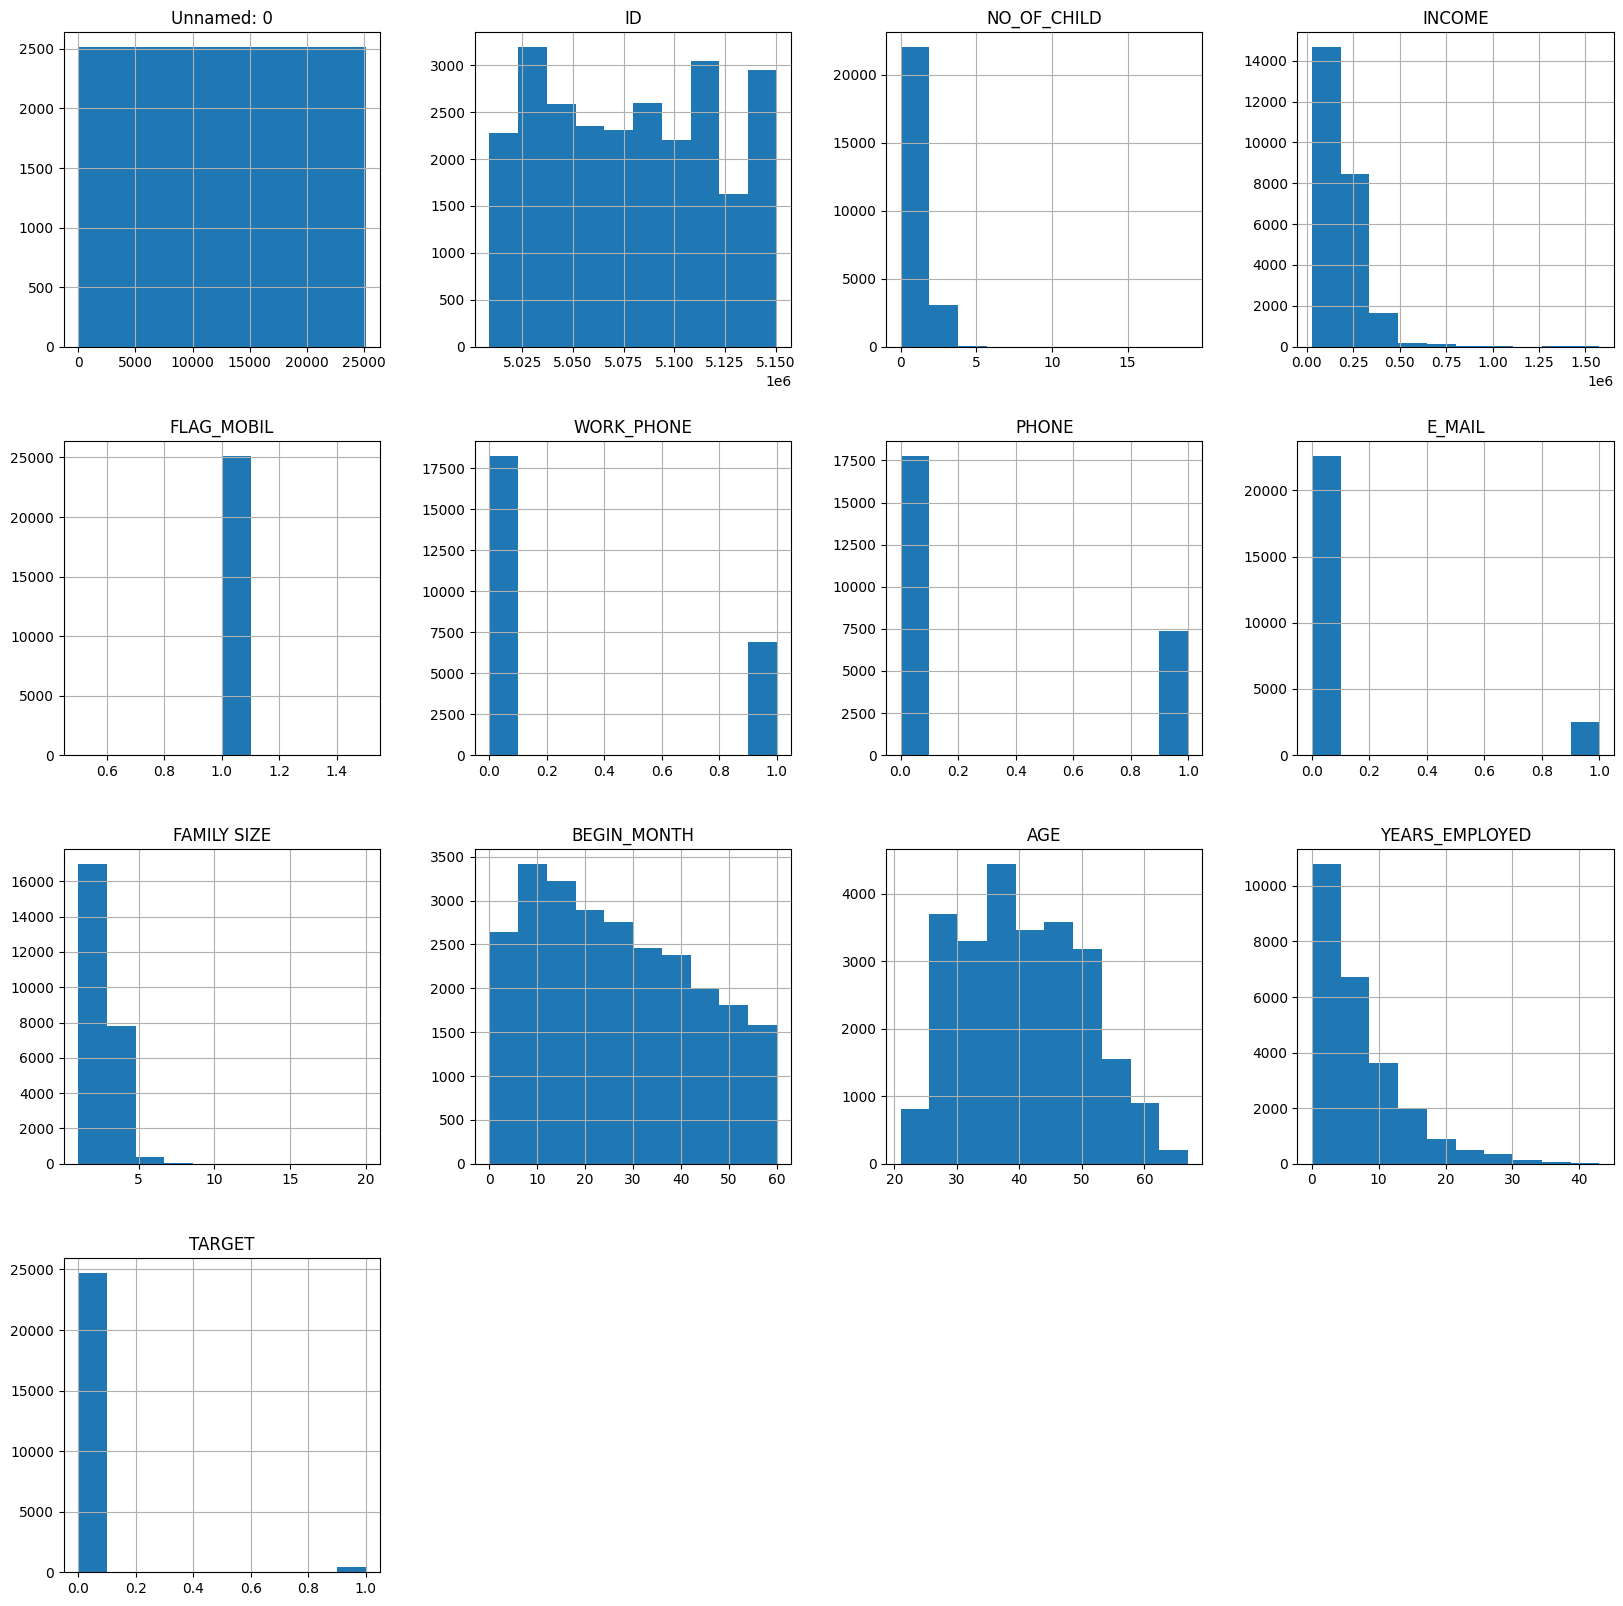

In [2]:
PATH = "D:\\Introduction-to-Machine-Learning_MTH10353\\Homework\\7\\credit_fraud.csv" # Path to your file


df = pd.read_csv(PATH)
df.head()
#ToDo: Show histogram of dataframe
df.hist(figsize=(20, 20))
plt.show()

## Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      25134 non-null  int64  
 1   ID              25134 non-null  int64  
 2   GENDER          25134 non-null  object 
 3   CAR             25134 non-null  object 
 4   REALITY         25134 non-null  object 
 5   NO_OF_CHILD     25134 non-null  int64  
 6   INCOME          25134 non-null  float64
 7   INCOME_TYPE     25134 non-null  object 
 8   EDUCATION_TYPE  25134 non-null  object 
 9   FAMILY_TYPE     25134 non-null  object 
 10  HOUSE_TYPE      25134 non-null  object 
 11  FLAG_MOBIL      25134 non-null  int64  
 12  WORK_PHONE      25134 non-null  int64  
 13  PHONE           25134 non-null  int64  
 14  E_MAIL          25134 non-null  int64  
 15  FAMILY SIZE     25134 non-null  float64
 16  BEGIN_MONTH     25134 non-null  int64  
 17  AGE             25134 non-null 

None

Unnamed: 0        0
ID                0
GENDER            0
CAR               0
REALITY           0
NO_OF_CHILD       0
INCOME            0
INCOME_TYPE       0
EDUCATION_TYPE    0
FAMILY_TYPE       0
HOUSE_TYPE        0
FLAG_MOBIL        0
WORK_PHONE        0
PHONE             0
E_MAIL            0
FAMILY SIZE       0
BEGIN_MONTH       0
AGE               0
YEARS_EMPLOYED    0
TARGET            0
dtype: int64

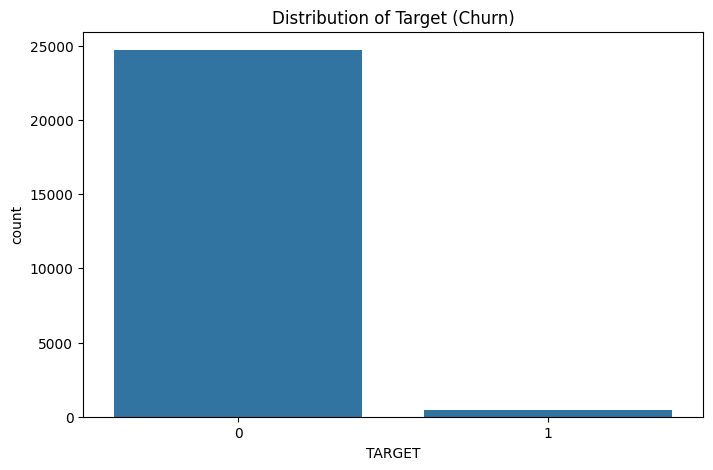

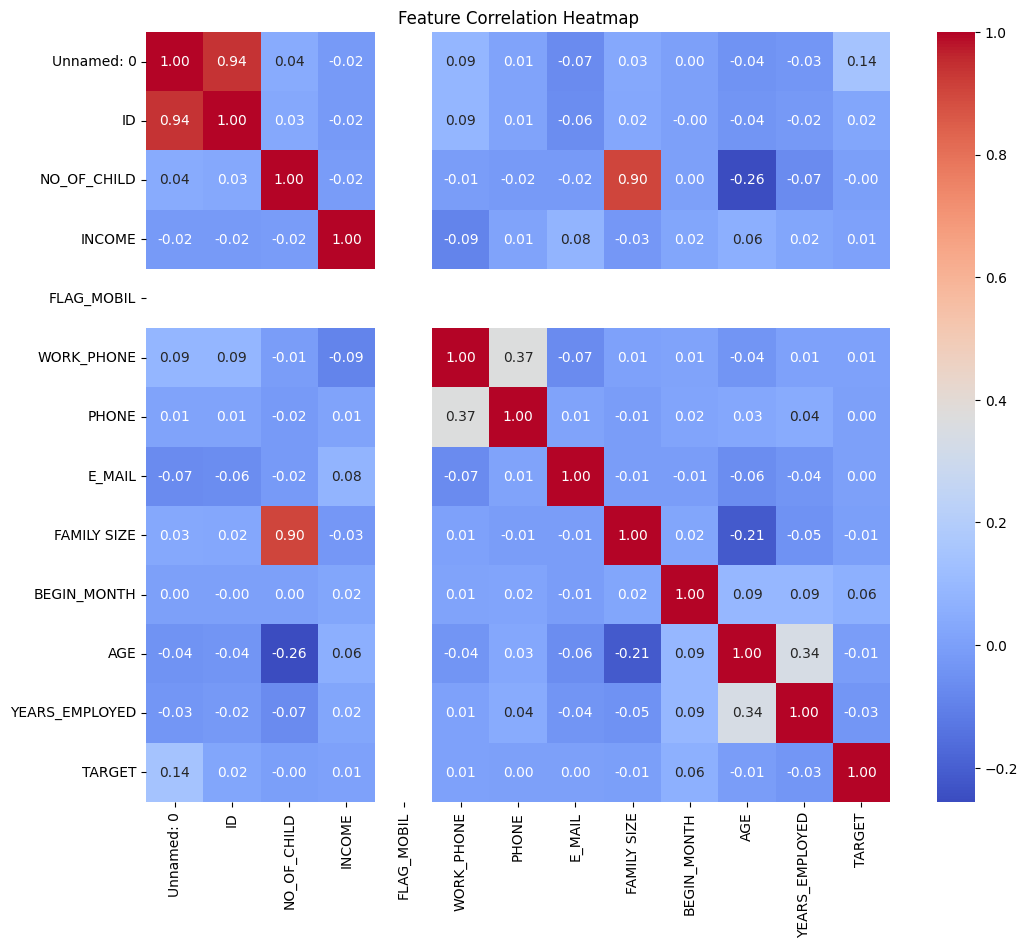

In [3]:
# Data analysis
# Todo: analyze your data here
display(df.info())
display(df.isnull().sum())

plt.figure(figsize=(8, 5))
sns.countplot(x='TARGET', data=df)
plt.title('Distribution of Target (Churn)')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
df.head()

,Unnamed: 0,ID,GENDER,CAR,REALITY,NO_OF_CHILD,INCOME,INCOME_TYPE,EDUCATION_TYPE,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET
0,0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,2.0,29,59,3,0
1,1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8,0
2,2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
3,3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
4,4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8,0


In [5]:
df.shape

(25134, 20)

In [6]:
df.columns

Index(['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'INCOME',
       'INCOME_TYPE', 'EDUCATION_TYPE', 'FAMILY_TYPE', 'HOUSE_TYPE',
       'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE',
       'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      25134 non-null  int64  
 1   ID              25134 non-null  int64  
 2   GENDER          25134 non-null  object 
 3   CAR             25134 non-null  object 
 4   REALITY         25134 non-null  object 
 5   NO_OF_CHILD     25134 non-null  int64  
 6   INCOME          25134 non-null  float64
 7   INCOME_TYPE     25134 non-null  object 
 8   EDUCATION_TYPE  25134 non-null  object 
 9   FAMILY_TYPE     25134 non-null  object 
 10  HOUSE_TYPE      25134 non-null  object 
 11  FLAG_MOBIL      25134 non-null  int64  
 12  WORK_PHONE      25134 non-null  int64  
 13  PHONE           25134 non-null  int64  
 14  E_MAIL          25134 non-null  int64  
 15  FAMILY SIZE     25134 non-null  float64
 16  BEGIN_MONTH     25134 non-null  int64  
 17  AGE             25134 non-null 

In [8]:
df.describe()

,Unnamed: 0,ID,NO_OF_CHILD,INCOME,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET
count,25134.000000,2.513400e+04,25134.000000,2.513400e+04,25134.0,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000,25134.000000
mean,12566.500000,5.078838e+06,0.512334,1.948339e+05,1.0,0.273812,0.292791,0.100660,2.294064,26.120594,40.536166,7.204106,0.016790
std,7255.705169,4.194102e+04,0.787785,1.045110e+05,0.0,0.445923,0.455052,0.300885,0.947590,16.439658,9.559474,6.414231,0.128486
min,0.000000,5.008806e+06,0.000000,2.700000e+04,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,21.000000,0.000000,0.000000
25%,6283.250000,5.042228e+06,0.000000,1.350000e+05,1.0,0.000000,0.000000,0.000000,2.000000,12.000000,33.000000,3.000000,0.000000
50%,12566.500000,5.079004e+06,0.000000,1.800000e+05,1.0,0.000000,0.000000,0.000000,2.000000,24.000000,40.000000,5.000000,0.000000
75%,18849.750000,5.115604e+06,1.000000,2.250000e+05,1.0,1.000000,1.000000,0.000000,3.000000,39.000000,48.000000,10.000000,0.000000
max,25133.000000,5.150487e+06,19.000000,1.575000e+06,1.0,1.000000,1.000000,1.000000,20.000000,60.000000,67.000000,43.000000,1.000000


In [9]:
print("Missing values:")
df.isnull().sum()

Missing values:


Unnamed: 0        0
ID                0
GENDER            0
CAR               0
REALITY           0
NO_OF_CHILD       0
INCOME            0
INCOME_TYPE       0
EDUCATION_TYPE    0
FAMILY_TYPE       0
HOUSE_TYPE        0
FLAG_MOBIL        0
WORK_PHONE        0
PHONE             0
E_MAIL            0
FAMILY SIZE       0
BEGIN_MONTH       0
AGE               0
YEARS_EMPLOYED    0
TARGET            0
dtype: int64

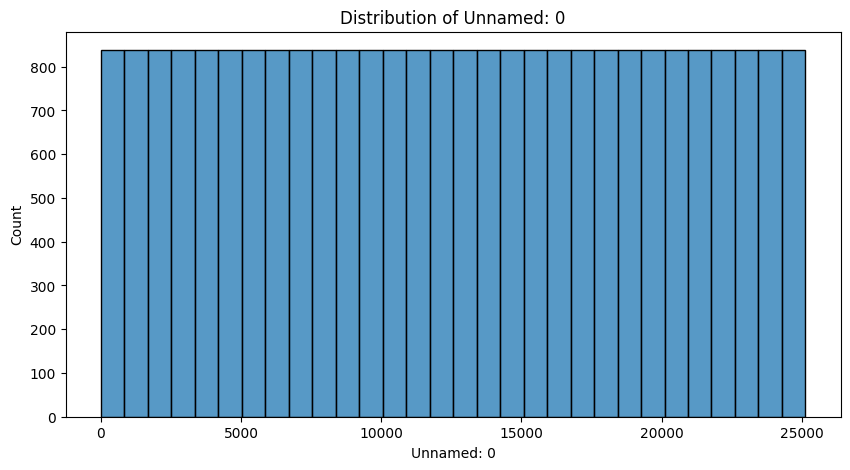

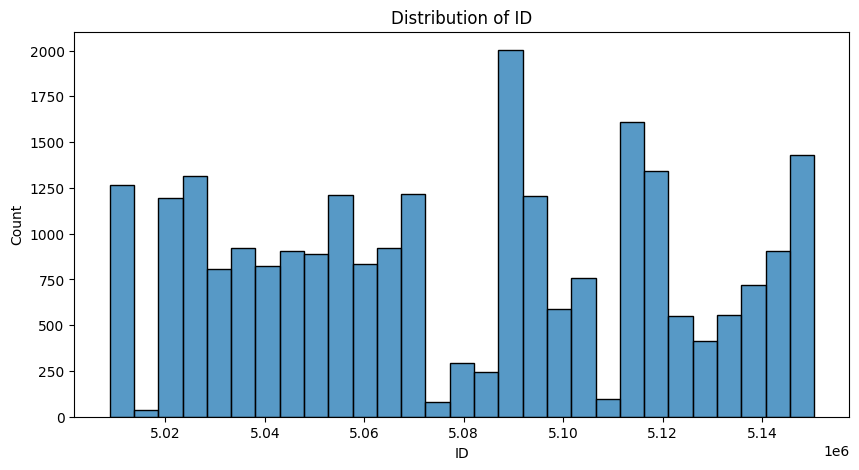

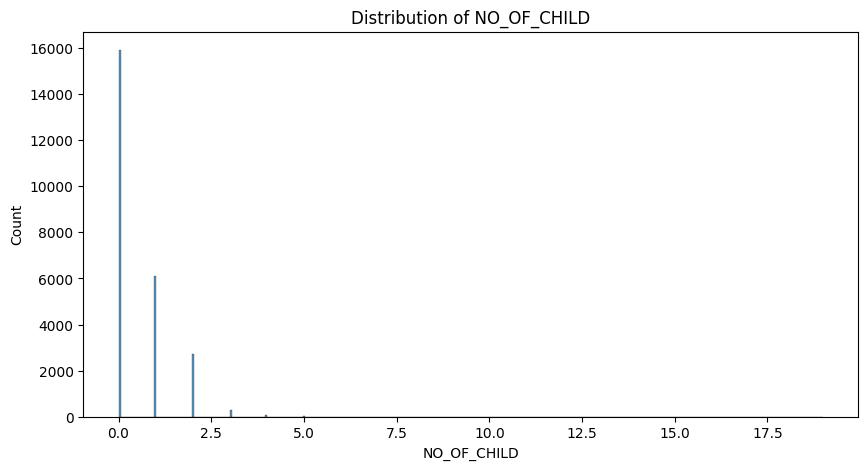

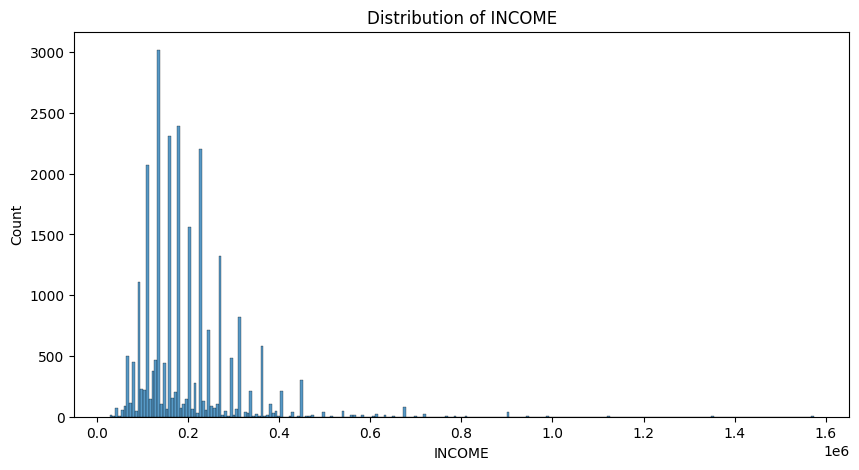

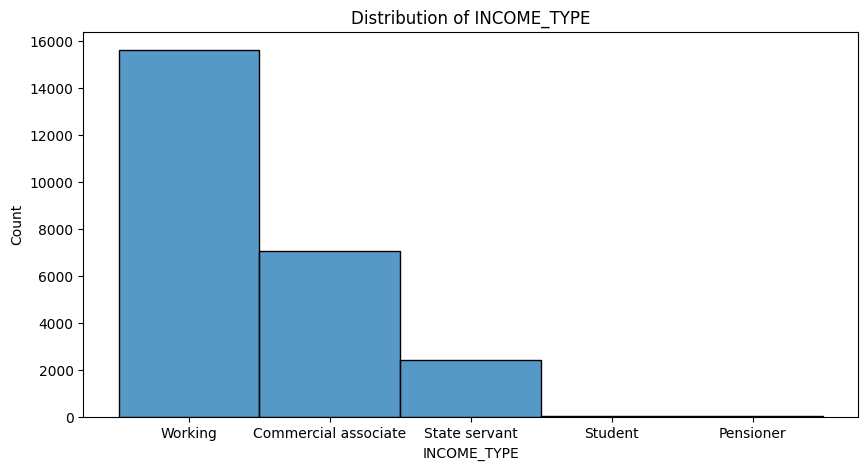

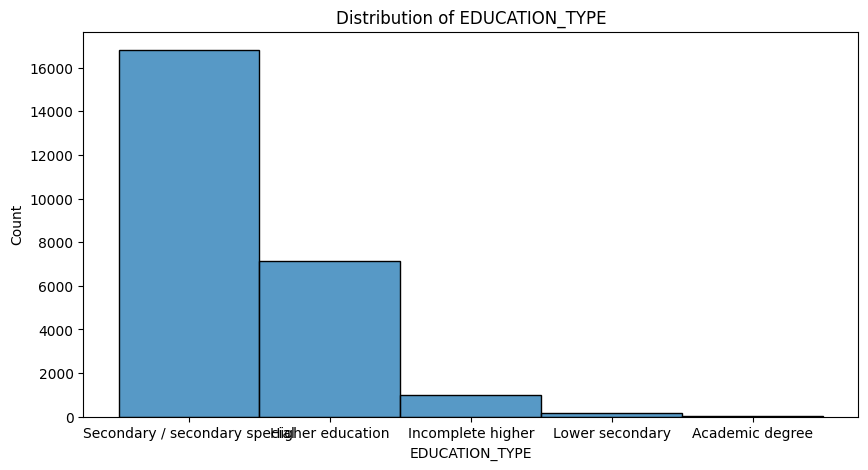

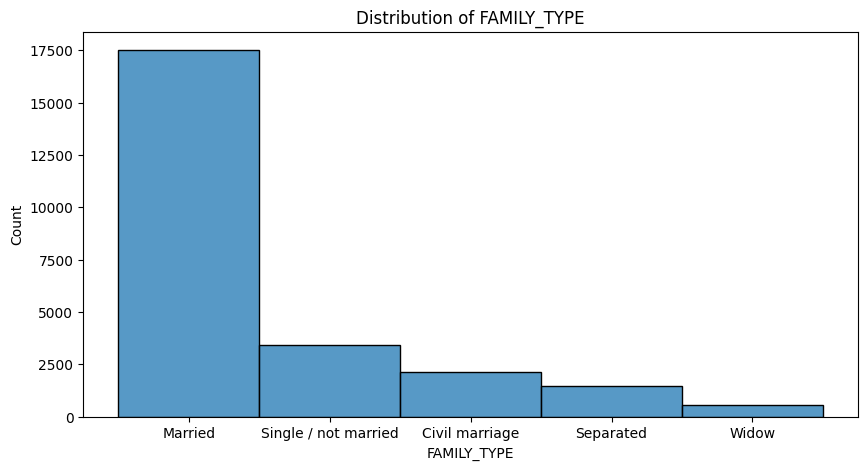

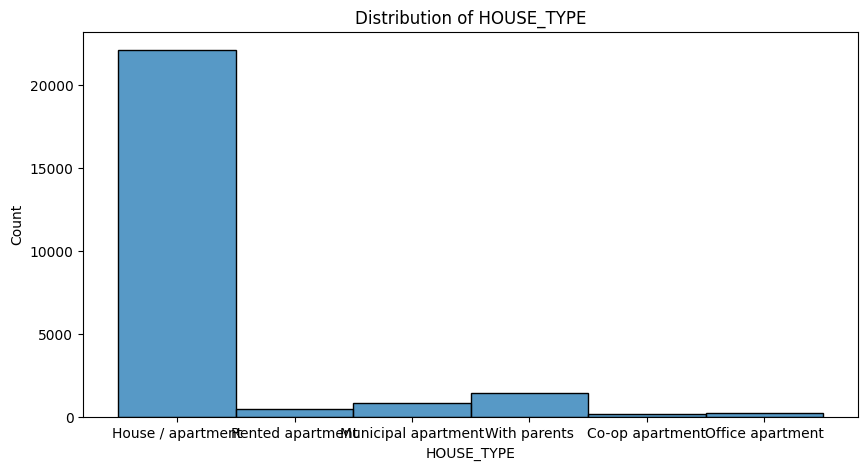

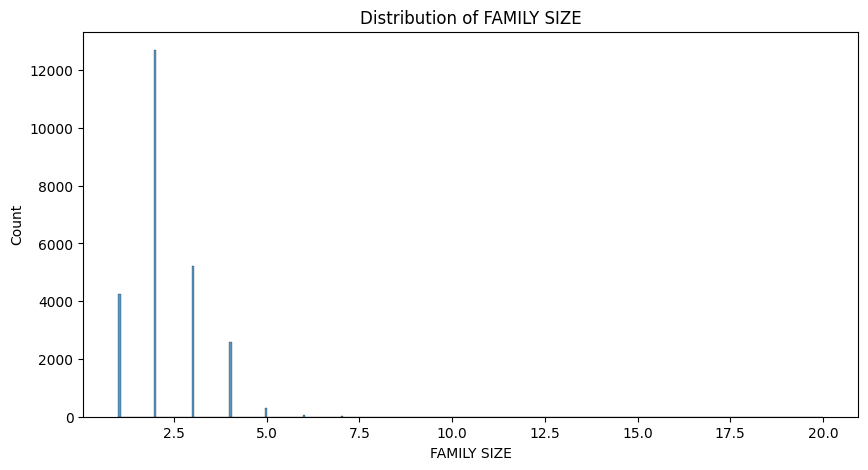

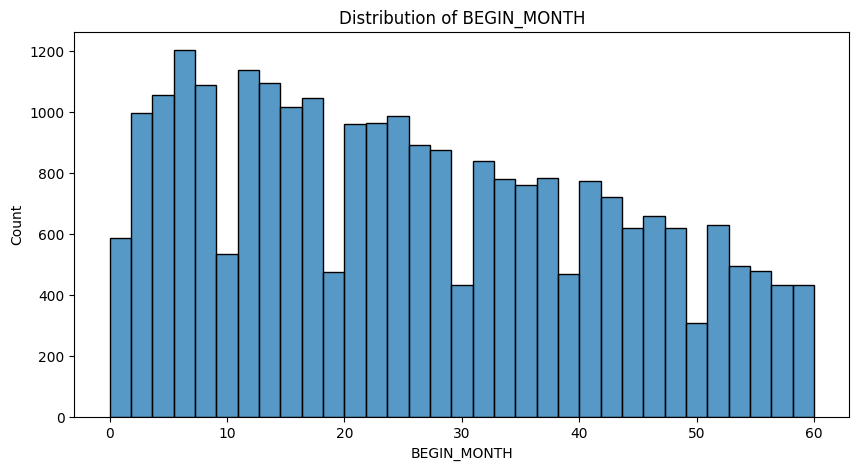

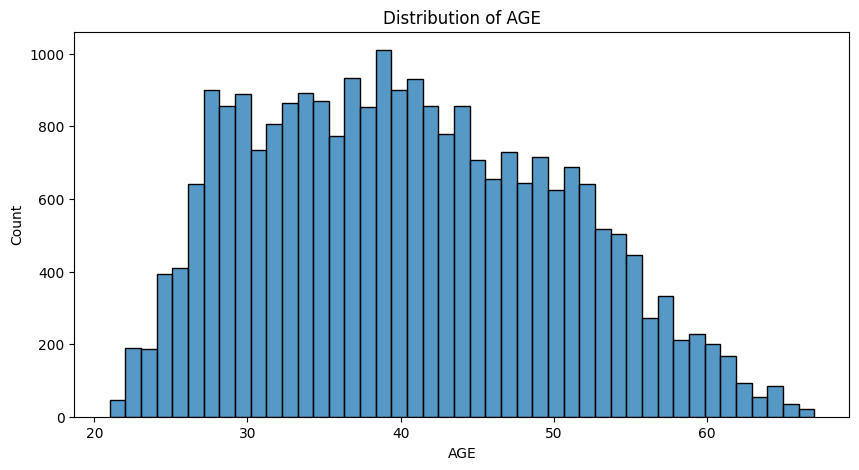

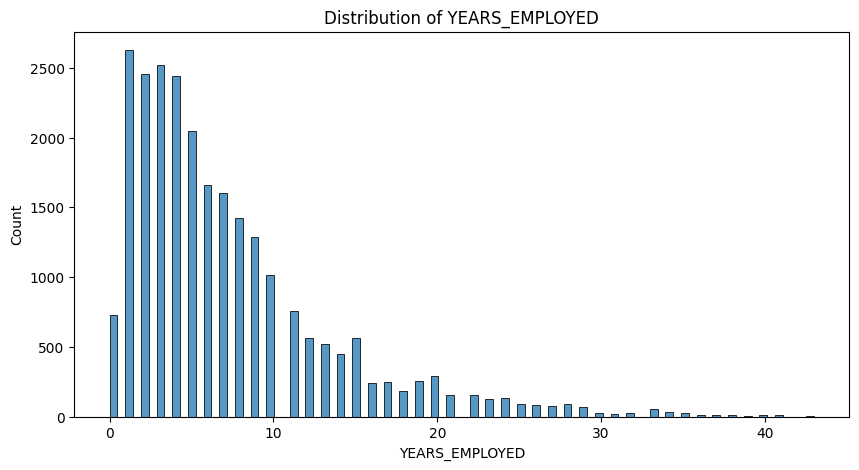

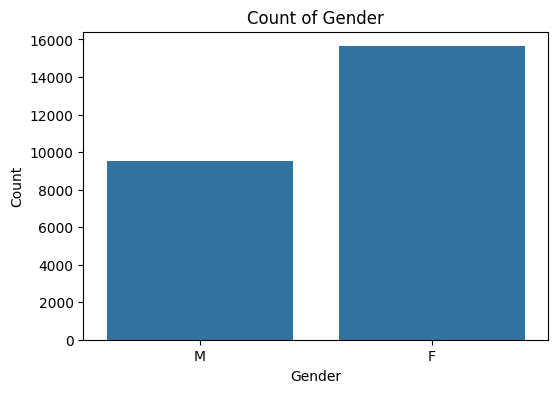

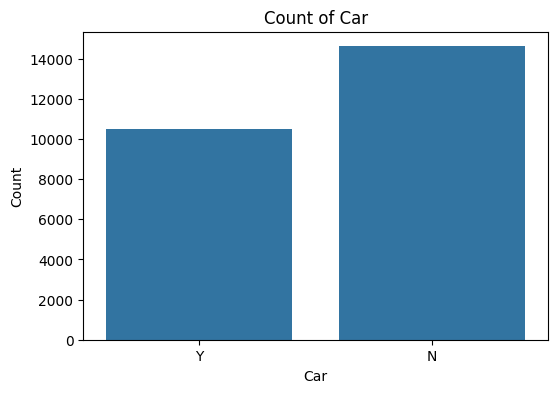

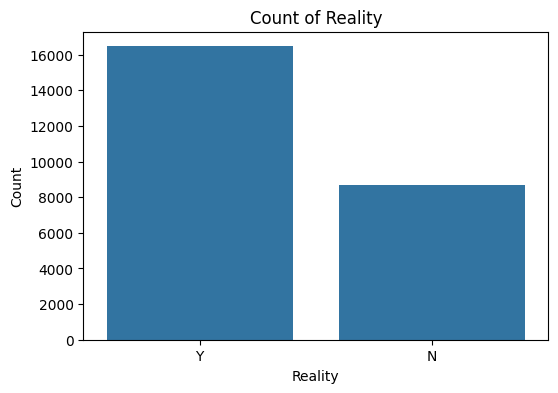

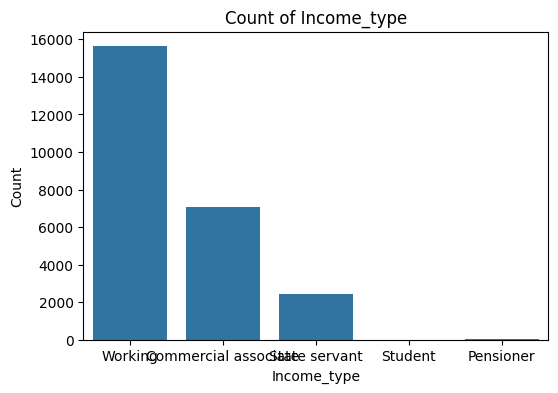

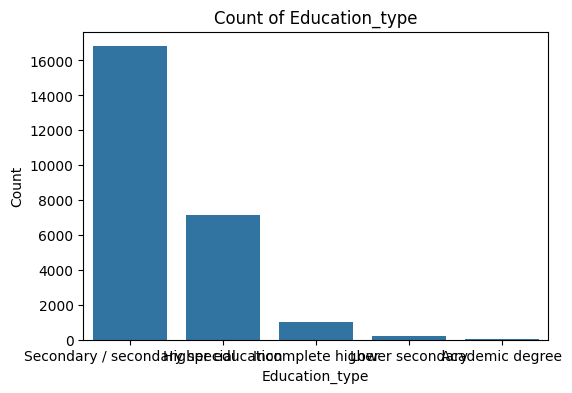

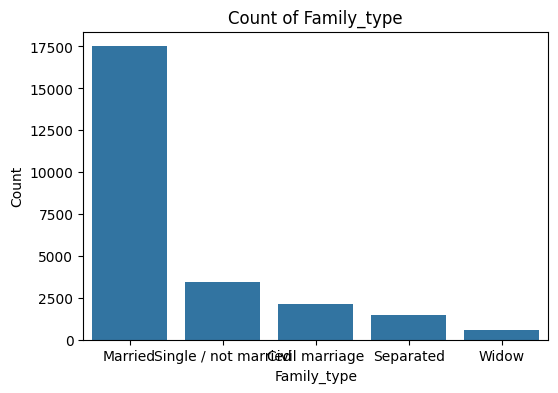

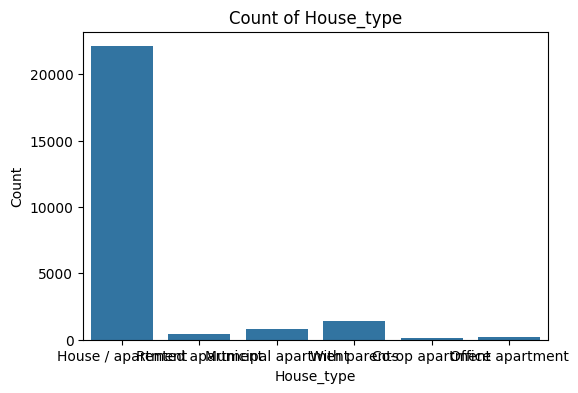

In [10]:
non_binary_columns = [col for col in df.columns if df[col].nunique() > 2]
for column in non_binary_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[column])
    plt.title(f"Distribution of {column}")
    plt.show()
    
categorical_col=df.select_dtypes(include=['object']).columns
for column in categorical_col:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[column])
    plt.title(f'Count of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Count')
    plt.show()

=> Same dataset as week 6

## Preprocessing

In [11]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df = df.dropna() 
    df = df.drop_duplicates()
    df = df[df['NO_OF_CHILD'] < 14]
    return df

In [12]:
df = preprocessing_data(df.copy())

## Feature Engineering

<Axes: >

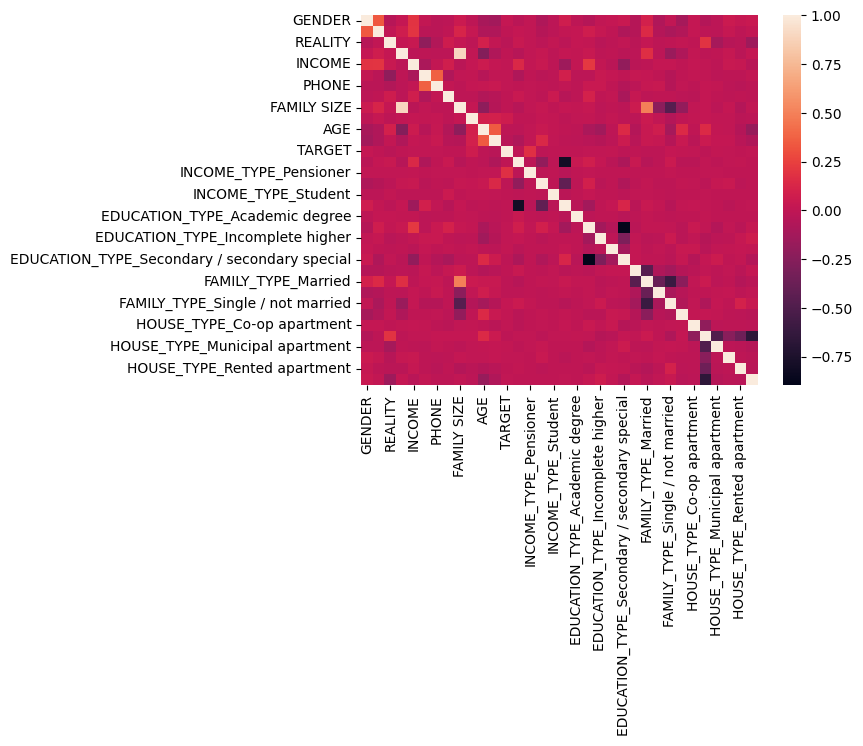

In [13]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    #Feature selection
    #Drop unecesary features
    df = df.drop(['Unnamed: 0'],axis=1)
    df = df.drop(['ID'],axis=1)
    df = df.drop(['FLAG_MOBIL'],axis=1)

    #Feature transfromation
    #Label encoding
    label_encoder = preprocessing.LabelEncoder()

    df['GENDER'] = label_encoder.fit_transform(df['GENDER'])
    df['CAR'] = label_encoder.fit_transform(df['CAR'])
    df['REALITY'] = label_encoder.fit_transform(df['REALITY'])

    #One-hot encoding
    df = pd.get_dummies(df, columns=['INCOME_TYPE'],dtype=int)
    df = pd.get_dummies(df, columns=['EDUCATION_TYPE'],dtype=int)
    df = pd.get_dummies(df, columns=['FAMILY_TYPE'],dtype=int)
    df = pd.get_dummies(df, columns=['HOUSE_TYPE'],dtype=int)

    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [14]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    columns = df.columns.tolist()
    columns.remove('TARGET')
    
    X = df[columns]
    y = df['TARGET']
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [15]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 69
TRAIN_SIZE = 0.7

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

Because we knew model is imbalanced from Lab 6, we will use RandomizedSearchCV to tune hyperparameters of MLPClassifier with SMOTE in the pipeline.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as L
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

nan_cols = ['INCOME', 'AGE'] 
zero_cols = [] 


ct = ColumnTransformer(
    [
        ("nan_imputer", SimpleImputer(missing_values=np.nan, strategy="median"), nan_cols),
        ("zero_imputer", SimpleImputer(missing_values=0, strategy="mean"), zero_cols) 
    ],
    remainder="passthrough"
)

# Fit và Transform
trainX_imputed = ct.fit_transform(trainX)
testX_imputed = ct.transform(testX)

# Scale dataset
scaler = StandardScaler()
trainX_scaled = scaler.fit_transform(trainX_imputed)
testX_scaled = scaler.transform(testX_imputed)

smote = SMOTE(random_state=RANDOM_STATE)
trainX_resampled, trainY_resampled = smote.fit_resample(trainX_scaled, trainY)

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long) 
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return {"feature": self.X[idx], "label": self.y[idx]}

# Batch size = 16 
BATCH_SIZE = 16

train_dataset = CreditDataset(trainX_resampled, trainY_resampled)
test_dataset = CreditDataset(testX_scaled, testY)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Model
class Model_MLP(L.LightningModule):
    def __init__(self, input_dim, num_classes=2, learning_rate=5e-3):
        super(Model_MLP, self).__init__()  
        self.learning_rate = learning_rate  
        
        # Tạo mô hình MLP: Input -> 32 -> ReLU -> 16 -> ReLU -> Output
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 32), 
            torch.nn.ReLU(),                  
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, num_classes), 
        )

    def forward(self, x):
        return self.mlp(x) 

    def training_step(self, batch, batch_idx):
        x = batch["feature"]  
        y = batch["label"]    
        y_pred = self(x)      
        loss = torch.nn.CrossEntropyLoss()(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)  
        return loss  

    def validation_step(self, batch, batch_idx):
        x = batch["feature"]  
        y = batch["label"]    
        y_pred = self(x)      
        val_loss = torch.nn.CrossEntropyLoss()(y_pred, y)
        self.log('val_loss', val_loss, prog_bar=True)  
        return val_loss  

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer  

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.eval()
        y_true = []
        y_pred = []
        device = self.device

        for batch in dataloader:
            x = batch["feature"].to(device)
            y = batch["label"].to(device)

            logits = self(x)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

        # Print metrics
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted')
        rec = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')

        print("=== EVALUATION METRICS ===")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print("\nClassification Report:\n", classification_report(y_true, y_pred))

        return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Train
input_dim = trainX_resampled.shape[1]
model = Model_MLP(input_dim=input_dim, num_classes=2)

# epoch = 50
trainer = L.Trainer(max_epochs=50)

trainer.fit(model, train_dataloaders=train_loader)
metrics = model.evaluate(test_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  1.7 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.7 K                                                                                                
Total estimated model params size (MB): 0.007                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


=== EVALUATION METRICS ===
Accuracy:  0.9629
Precision: 0.9779
Recall:    0.9629
F1-Score:  0.9699

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      7434
           1       0.13      0.30      0.18       105

    accuracy                           0.96      7539
   macro avg       0.56      0.63      0.58      7539
weighted avg       0.98      0.96      0.97      7539



In [ ]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return (
        "6. Main metric: F1-Macro / Weighted F1-Score. Because the dataset is highly imbalanced (Class 0 is approximately 70 times larger than Class 1), Accuracy is a misleading metric (predicting all 0s still yields ~96% accuracy). F1-Score balances Precision and Recall for the minority class. \n"
        "Main model & params: Deep learning MLP. It consists of 2 hidden layers (32 and 16 nodes) with ReLU activation, optimized using Adam for 50 epochs with a batch size of 16. Since neural networks often struggle with skewed data, SMOTE was applied in the preprocessing step to artificially balance the training data and force the network to learn the minority class.\n"
        "Other conclusion: By using a smaller network architecture in PyTorch combined with SMOTE, the model successfully avoided collapsing into a majority-class predictor. "
        "It achieved a Recall of 0.30 for Class 1 (catching 30% of actual fraud/default cases). However, this still comes at the cost of Precision, which is now 0.13 (indicating high False Positives). This result shows that while deep learning model can identify some minority cases, extreme tabular imbalance remains highly challenging for standard MLPs. It reinforces the idea that tree-based ensemble models (like Random Forest or XGBoost) are generally more naturally suited for this type of tabular data."
    )